<a href="https://colab.research.google.com/github/juanfeolguin123-cmyk/portafolio-de-inversion/blob/main/portafolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Precio: 1000
Valor portafolio: 10000
Precio: 1020
Valor portafolio: 10000
Precio: 980
Valor portafolio: 9990.2
Precio: 1100
Valor portafolio: 10110.2
Precio: 1200
Valor portafolio: 10210.2


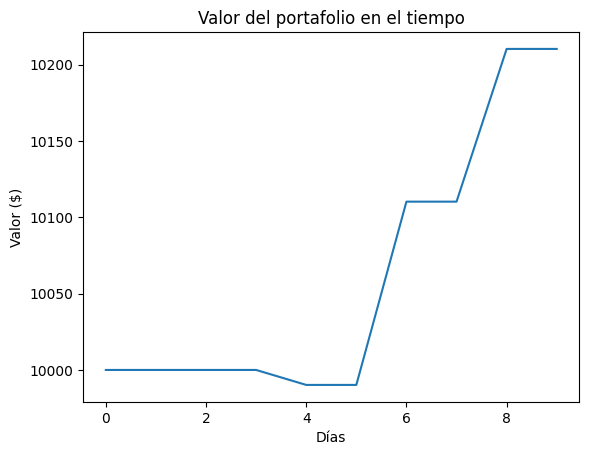

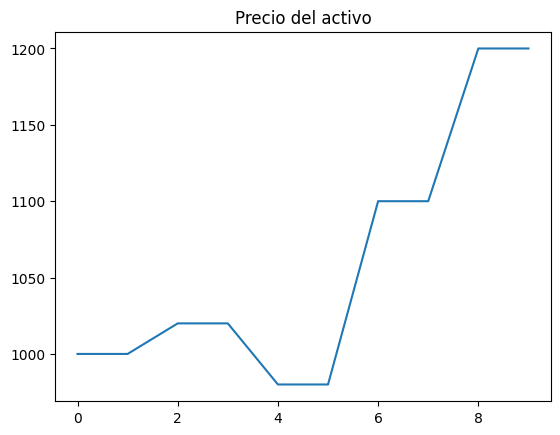

Rentabilidad: 2.10%


In [1]:
import matplotlib.pyplot as plt

#creacion clase activo para iniciar
class Activo:
    def __init__(self, nombre, precio):
        self.nombre = nombre
        self.precio = precio

class Portafolio:
    def __init__(self, capital_inicial):
        self.efectivo = capital_inicial
        self.activos = {}


# anexamos costos de comision del broker
    def comprar(self, activo, cantidad):
      comision = 0.01  # 1%

      costo = activo.precio * cantidad
      costo_total = costo * (1 + comision)

      if costo_total > self.efectivo:
        print("No tienes suficiente dinero")
        return

      self.efectivo -= costo_total

      if activo.nombre in self.activos:
        self.activos[activo.nombre]["cantidad"] += cantidad
      else:
        self.activos[activo.nombre] = {
            "activo": activo,
            "cantidad": cantidad
        }



    def valor_total(self):
      total = self.efectivo

      for item in self.activos.values():
          activo = item["activo"]
          cantidad = item["cantidad"]
          total += activo.precio * cantidad

      return total

# validacion de que el activo esta creado correctamente
tesla = Activo("Tesla", 1000)

bono = Activo("Bono", 100)
cdt = Activo("CDT", 100)


port = Portafolio(10000)

port.comprar(tesla, 3)

precios = [1000, 1020, 980, 1100, 1200]

tesla = Activo("Tesla", 1000)
port = Portafolio(10000)

# creamos estas listas para guardar los precios de los cierres de cada dia
historial_valor = []
historial_precios = []

for i, precio in enumerate(precios):
    tesla.precio = precio

    # Dividendo en un dia al azar
    if i == 2:
        dividendo = 10

        if "Tesla" in port.activos:
            cantidad = port.activos["Tesla"]["cantidad"]
            pago = cantidad * dividendo

            port.efectivo += pago
            tesla.precio *= 0.98

            print("Dividendo recibido:", pago)

    # analisis para ejecutar la operacion
    if precio < 1000:
        port.comprar(tesla, 1)

    valor = port.valor_total()

    historial_valor.append(valor)
    historial_precios.append(tesla.precio)

# anexamos la variable de valor para que el ciclo vaya guardando los precios al
# cierre de cada dia con el find e elaborar la grafica
    valor = port.valor_total()

    historial_valor.append(valor)
    historial_precios.append(precio)

    print("Precio:", precio)
    print("Valor portafolio:", valor)

    #print(historial_valor)
# grafica del valor del portafolio con el tiempo
plt.plot(historial_valor)
plt.title("Valor del portafolio en el tiempo")
plt.xlabel("Días")
plt.ylabel("Valor ($)")
plt.show()
#grafica del precio a lo largo de los dias
plt.plot(historial_precios)
plt.title("Precio del activo")
plt.show()


capital_inicial = 10000
valor_final = port.valor_total()

rentabilidad = (valor_final - capital_inicial) / capital_inicial * 100

print(f"Rentabilidad: {rentabilidad:.2f}%")








In [3]:
#instalacion del paquete yfinance
!pip install yfinance


In [4]:

import yfinance as yf


In [7]:
#bajamos la data de los cierres de tesla desde dos fechas distintas
data = yf.download("TSLA", start="2023-01-01", end="2023-03-01")





/tmp/ipykernel_8971/1514545271.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("TSLA", start="2023-01-01", end="2023-03-01")
[*********************100%***********************]  1 of 1 completed


In [11]:
print(data.head())



Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2023-01-03  108.099998  118.800003  104.639999  118.470001  231402800
2023-01-04  113.639999  114.589996  107.519997  109.110001  180389000
2023-01-05  110.339996  111.750000  107.160004  110.510002  157986300
2023-01-06  113.059998  114.389999  101.809998  103.000000  220911100
2023-01-09  119.769997  123.519997  117.110001  118.959999  190284000


In [15]:
precios = data["Close"]["TSLA"].tolist()

print(data["Close"])




Ticker            TSLA
Date                  
2023-01-03  108.099998
2023-01-04  113.639999
2023-01-05  110.339996
2023-01-06  113.059998
2023-01-09  119.769997
2023-01-10  118.849998
2023-01-11  123.220001
2023-01-12  123.559998
2023-01-13  122.400002
2023-01-17  131.490005
2023-01-18  128.779999
2023-01-19  127.169998
2023-01-20  133.419998
2023-01-23  143.750000
2023-01-24  143.889999
2023-01-25  144.429993
2023-01-26  160.270004
2023-01-27  177.899994
2023-01-30  166.660004
2023-01-31  173.220001
2023-02-01  181.410004
2023-02-02  188.270004
2023-02-03  189.979996
2023-02-06  194.759995
2023-02-07  196.809998
2023-02-08  201.289993
2023-02-09  207.320007
2023-02-10  196.889999
2023-02-13  194.639999
2023-02-14  209.250000
2023-02-15  214.240005
2023-02-16  202.039993
2023-02-17  208.309998
2023-02-21  197.369995
2023-02-22  200.860001
2023-02-23  202.070007
2023-02-24  196.880005
2023-02-27  207.630005
2023-02-28  205.710007
